# Libraries

In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 8.0 MB/s eta 0:00:00


In [2]:
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import json
import importlib.util
import torch



In [3]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!git clone -b feature/cv-yolo-detection https://github.com/Govind-2004/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization.git

Cloning into 'AI_Adaptive_Traffic_Analysis_and_Signal_Optimization'...
remote: Enumerating objects: 221, done.
remote: Counting objects: 100% (221/221), done.
remote: Compressing objects: 100% (190/190), done.
remote: Total 221 (delta 71), reused 46 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (221/221), 10.11 MiB | 13.00 MiB/s, done.
Resolving deltas: 100% (71/71), done.


In [5]:
%cd /content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization

/content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization


# Load and generate track data

In [6]:
video_path = "/content/drive/MyDrive/Colab Notebooks/Datasets /Capstone_traffic/Demo/HnVideoEditor_2026_09_20_102852705.mp4"

print("Video exists:", os.path.exists(video_path))

Video exists: True


In [7]:
repo_path = "/content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization"

tracker_path = f"{repo_path}/cv/tracking/tracker.py"
detector_path = f"{repo_path}/cv/detection/detector.py"

# Load detector.py
spec = importlib.util.spec_from_file_location("detector", detector_path)
detector = importlib.util.module_from_spec(spec)
spec.loader.exec_module(detector)

# Load tracker.py
spec = importlib.util.spec_from_file_location("tracker", tracker_path)
tracker = importlib.util.module_from_spec(spec)
spec.loader.exec_module(tracker)

model, device = detector.load_model()

print("Device:", device)
print("Vehicle classes:", detector.VEHICLE_CLASSES)
print("Tracker module loaded:", hasattr(tracker, "track_vehicles"))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Device: cpu
Vehicle classes: {2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}
Tracker module loaded: True


In [9]:
# Generating the tracking data
video_path = "/content/drive/MyDrive/Colab Notebooks/Datasets /Capstone_traffic/Demo/HnVideoEditor_2026_09_20_102852705.mp4"

tracking_rows = []

results = tracker.track_vehicles(
    video_path=video_path,
    model=model,
    classes=detector.VEHICLE_CLASSES,
    tracker="bytetrack.yaml",
    conf=0.35
)

for frame_idx, result in enumerate(results):

    if result.boxes.id is None:
        continue

    track_ids = result.boxes.id.cpu().numpy().astype(int)
    classes = result.boxes.cls.cpu().numpy().astype(int)
    boxes = result.boxes.xyxy.cpu().numpy()

    for track_id, cls, box in zip(track_ids, classes, boxes):

        x1, y1, x2, y2 = box

        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2

        tracking_rows.append({
            "frame": frame_idx,
            "track_id": track_id,
            "class": detector.VEHICLE_CLASSES.get(cls, "unknown"),
            "center_x": center_x,
            "center_y": center_y
        })

tracking_df = pd.DataFrame(tracking_rows)

print("Tracking rows:", len(tracking_df))
print("Unique vehicles:", tracking_df["track_id"].nunique())
print(tracking_df.head())

Tracking rows: 10014
Unique vehicles: 79
   frame  track_id class     center_x    center_y
0      0         1   car   783.292114  860.818237
1      0         2   car   954.993408  549.877625
2      0         3   car  1199.869751  883.647644
3      1         1   car   783.704834  862.444885
4      1         2   car   954.989136  549.677368


In [10]:
output_dir = f"{repo_path}/cv/output/traffic_states"
os.makedirs(output_dir, exist_ok=True)

csv_path = f"{output_dir}/tracking_data.csv"

tracking_df.to_csv(csv_path, index=False)

print("Saved:", csv_path)
print("File exists:", os.path.exists(csv_path))
print("File size:", round(os.path.getsize(csv_path) / 1024, 2), "KB")

Saved: /content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization/cv/output/traffic_states/tracking_data.csv
File exists: True
File size: 296.59 KB


In [11]:
tracking_csv = f"{repo_path}/cv/output/traffic_states/tracking_data.csv"

df = pd.read_csv(tracking_csv)

print("Rows:", len(df))
print("Unique vehicles:", df["track_id"].nunique())
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

Rows: 10014
Unique vehicles: 79
Columns: ['frame', 'track_id', 'class', 'center_x', 'center_y']

Missing values:
frame       0
track_id    0
class       0
center_x    0
center_y    0
dtype: int64


In [12]:
# applyin roi
roi_path = f"{repo_path}/cv/traffic/roi.py"

spec = importlib.util.spec_from_file_location("roi_module", roi_path)
roi_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(roi_module)

roi_points = [
    (500, 580),   # top-left, road edge near horizon
    (1040, 500),   # top-right, road edge near horizon
    (2000, 1400),  # bottom-right, road edge at frame's right side
    (450, 1400)    # bottom-left, road edge near the barrier
]

df_roi = roi_module.assign_roi_and_direction(
    df,
    roi_points,
    direction="north"
)

print("Original rows:", len(df))
print("ROI rows:", len(df_roi))
print("Dropped rows:", len(df) - len(df_roi))
print("Unique vehicles in ROI:", df_roi["track_id"].nunique())

Original rows: 10014
ROI rows: 7034
Dropped rows: 2980
Unique vehicles in ROI: 53


In [13]:
# Pixel speed
speed_path = f"{repo_path}/cv/traffic/speed.py"

spec = importlib.util.spec_from_file_location("speed_module", speed_path)
speed_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(speed_module)

FPS = 25
MAX_FRAME_GAP = 5

df_speed = speed_module.compute_pixel_speed(
    df_roi,
    fps=FPS,
    max_frame_gap=MAX_FRAME_GAP
)

print("Valid speed observations:", len(df_speed))
print("Unique vehicles:", df_speed["track_id"].nunique())

print("\nPixel speed statistics:")
print(df_speed["pixel_speed"].describe())

Valid speed observations: 6913
Unique vehicles: 45

Pixel speed statistics:
count    6913.000000
mean       31.968448
std        54.596423
min         0.014142
25%         2.460878
50%         7.941941
75%        39.057072
max       786.234048
Name: pixel_speed, dtype: float64


# Inspect the speed distribution

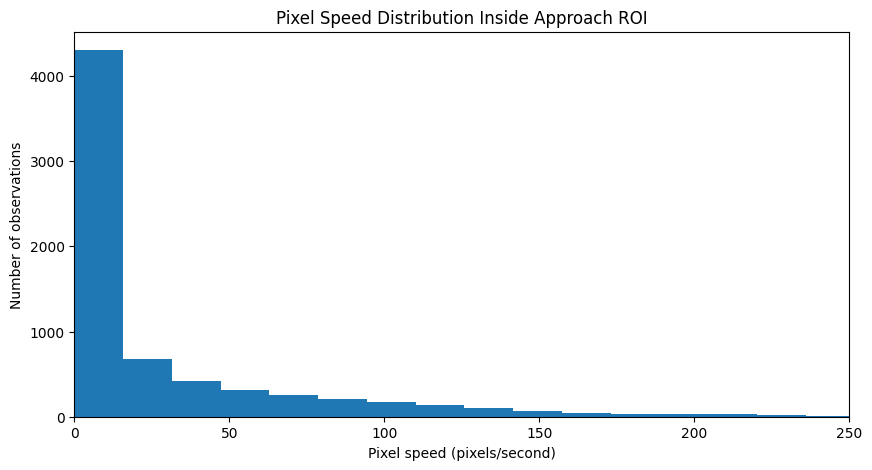

In [14]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_speed["pixel_speed"],
    bins=50
)

plt.xlabel("Pixel speed (pixels/second)")
plt.ylabel("Number of observations")
plt.title("Pixel Speed Distribution Inside Approach ROI")
plt.xlim(0, 250)

plt.show()

In [15]:
thresholds = [10, 20, 30, 40, 50]

for threshold in thresholds:
    slow_count = (df_speed["pixel_speed"] <= threshold).sum()
    percentage = (slow_count / len(df_speed)) * 100

    print(
        f"{threshold:>3} pixels/s → "
        f"{slow_count:>4} observations "
        f"({percentage:.2f}%)"
    )

 10 pixels/s → 3756 observations (54.33%)
 20 pixels/s → 4537 observations (65.63%)
 30 pixels/s → 4944 observations (71.52%)
 40 pixels/s → 5218 observations (75.48%)
 50 pixels/s → 5481 observations (79.29%)


In [16]:
FPS = 25
MIN_QUEUE_DURATION = 1.0
thresholds = [20, 30, 40, 50]

df_q = df_speed.sort_values(
    ["track_id", "frame"]
).copy()

df_q["is_slow"] = False

for threshold in thresholds:
    temp = df_q.copy()

    temp["is_slow"] = temp["pixel_speed"] <= threshold

    # Break a run when:
    # 1. the vehicle is no longer slow, or
    # 2. tracking has a large frame gap
    temp["frame_gap"] = (
        temp.groupby("track_id")["frame"].diff()
    )

    temp["run_break"] = (
        (~temp["is_slow"]) |
        (temp["frame_gap"] > 5) |
        (temp["frame_gap"].isna())
    )

    temp["run_id"] = (
        temp.groupby("track_id")["run_break"]
        .cumsum()
    )

    slow_runs = (
        temp[temp["is_slow"]]
        .groupby(["track_id", "run_id"])
        .agg(
            start_frame=("frame", "min"),
            end_frame=("frame", "max"),
            observations=("frame", "count")
        )
        .reset_index()
    )

    slow_runs["duration_seconds"] = (
        (slow_runs["end_frame"] - slow_runs["start_frame"])
        / FPS
    )

    persistent = slow_runs[
        slow_runs["duration_seconds"] >= MIN_QUEUE_DURATION
    ]

    print(
        f"{threshold:>3} pixels/s → "
        f"{len(persistent)} persistent slow runs, "
        f"{persistent['track_id'].nunique()} vehicles"
    )

 20 pixels/s → 42 persistent slow runs, 11 vehicles
 30 pixels/s → 57 persistent slow runs, 11 vehicles
 40 pixels/s → 60 persistent slow runs, 13 vehicles
 50 pixels/s → 54 persistent slow runs, 14 vehicles


In [18]:
import pandas as pd

def detect_queued_vehicles(
    df,
    speed_threshold,
    min_queue_duration,
    fps,
    max_frame_gap=5
):
    df = df.copy()
    df = df.sort_values(["track_id", "frame"]).reset_index(drop=True)

    df["frame_gap"] = df.groupby("track_id")["frame"].diff()

    df["is_slow"] = (
        df["pixel_speed"] <= speed_threshold
    )

    df["run_break"] = (
        (~df["is_slow"]) |
        (df["frame_gap"] > max_frame_gap) |
        (df["frame_gap"].isna())
    )

    df["run_id"] = (
        df.groupby("track_id")["run_break"]
        .cumsum()
    )

    slow_df = df[df["is_slow"]].copy()

    if slow_df.empty:
        return pd.DataFrame(
            columns=[
                "track_id",
                "run_id",
                "start_frame",
                "end_frame",
                "observations",
                "duration_seconds"
            ]
        )

    queue_runs = (
        slow_df
        .groupby(["track_id", "run_id"])
        .agg(
            start_frame=("frame", "min"),
            end_frame=("frame", "max"),
            observations=("frame", "count")
        )
        .reset_index()
    )

    queue_runs["duration_seconds"] = (
        (queue_runs["end_frame"] -
         queue_runs["start_frame"]) / fps
    )

    queue_runs = queue_runs[
        queue_runs["duration_seconds"] >= min_queue_duration
    ].copy()

    return queue_runs


def estimate_queue_length(df_queued):
    if df_queued.empty:
        return 0

    return int(df_queued["track_id"].nunique())

In [27]:
queued_runs = detect_queued_vehicles(
    df_speed,
    speed_threshold= 20,
    min_queue_duration=1.0,
    fps=25,
    max_frame_gap=5
)

print("Persistent queue runs:", len(queued_runs))
print("Queued vehicles:", estimate_queue_length(queued_runs))

display(queued_runs)

Persistent queue runs: 42
Queued vehicles: 11


,track_id,run_id,start_frame,end_frame,observations,duration_seconds
8,2,194,245,270,26,1.00
9,2,195,272,297,26,1.00
11,2,197,325,399,75,2.96
14,2,201,407,432,26,1.00
15,2,202,434,512,79,3.12
18,2,205,542,618,77,3.04
19,2,206,620,645,26,1.00
20,2,207,647,682,36,1.40
22,2,209,700,753,54,2.12
28,2,217,807,832,26,1.00


In [28]:
print("Unique track IDs:")
print(sorted(queued_runs["track_id"].unique()))

print("\nNumber of unique track IDs:")
print(queued_runs["track_id"].nunique())

Unique track IDs:
[np.int64(2), np.int64(5), np.int64(23), np.int64(26), np.int64(33), np.int64(47), np.int64(90), np.int64(126), np.int64(132), np.int64(134), np.int64(138)]

Number of unique track IDs:
11


In [29]:
queued_ids = sorted(queued_runs["track_id"].unique())

print("Queued vehicle IDs:", queued_ids)
print("Number of queued vehicles:", len(queued_ids))

Queued vehicle IDs: [np.int64(2), np.int64(5), np.int64(23), np.int64(26), np.int64(33), np.int64(47), np.int64(90), np.int64(126), np.int64(132), np.int64(134), np.int64(138)]
Number of queued vehicles: 11


In [30]:
import cv2
import matplotlib.pyplot as plt

# Pick one representative frame from each queued vehicle's
# detected queue period
sample_frames = []

for track_id in queued_ids:
    vehicle_rows = queued_runs[
        queued_runs["track_id"] == track_id
    ]

    # Take the middle of the first qualifying queue run
    row = vehicle_rows.iloc[0]

    sample_frame = int(
        (row["start_frame"] + row["end_frame"]) / 2
    )

    sample_frames.append(
        (track_id, sample_frame)
    )

print("Frames selected for visual validation:")
for track_id, frame_no in sample_frames:
    print(f"Vehicle {track_id} → frame {frame_no}")

Frames selected for visual validation:
Vehicle 2 → frame 257
Vehicle 5 → frame 271
Vehicle 23 → frame 566
Vehicle 26 → frame 472
Vehicle 33 → frame 488
Vehicle 47 → frame 646
Vehicle 90 → frame 952
Vehicle 126 → frame 978
Vehicle 132 → frame 1032
Vehicle 134 → frame 1219
Vehicle 138 → frame 1148


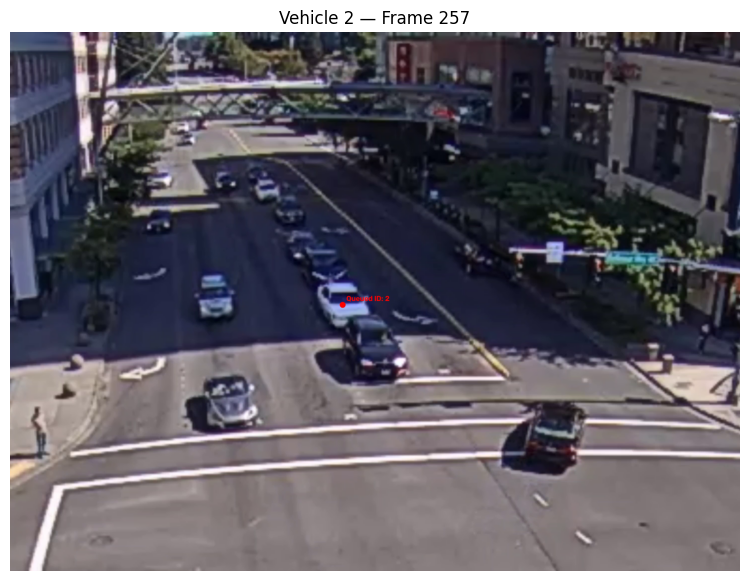

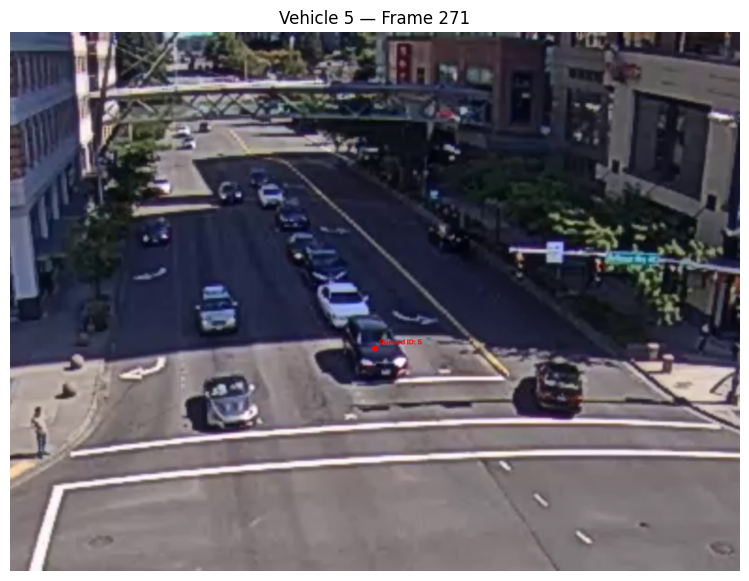

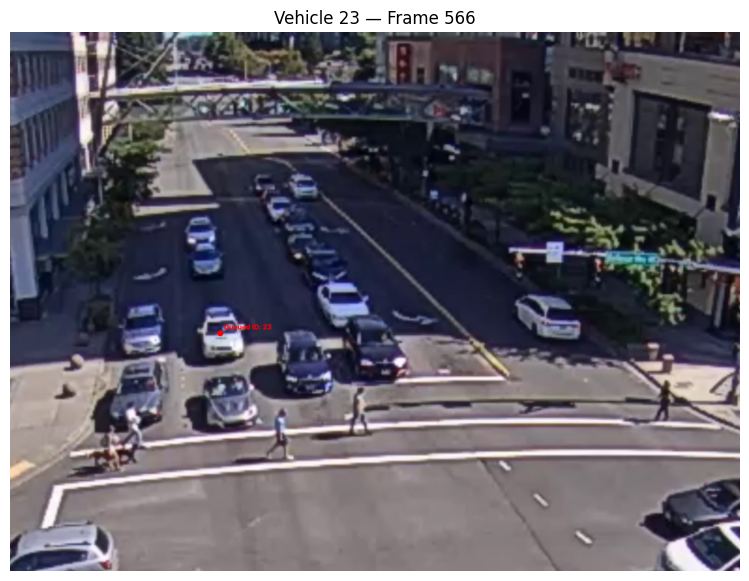

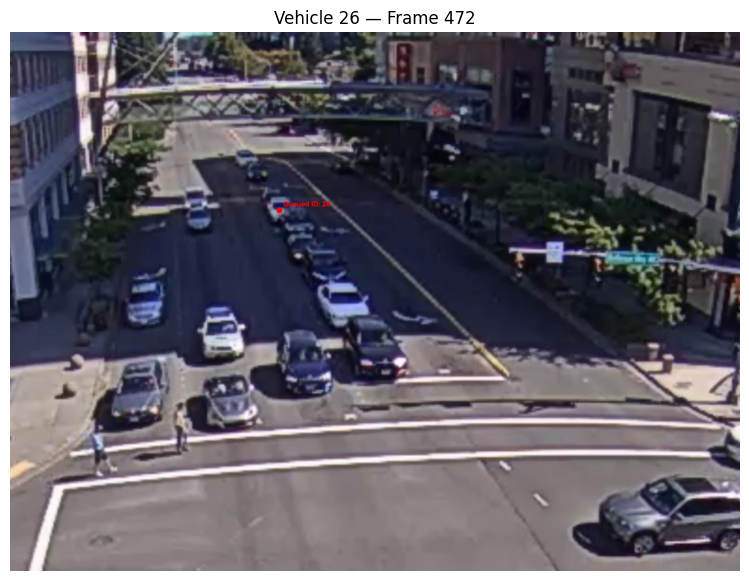

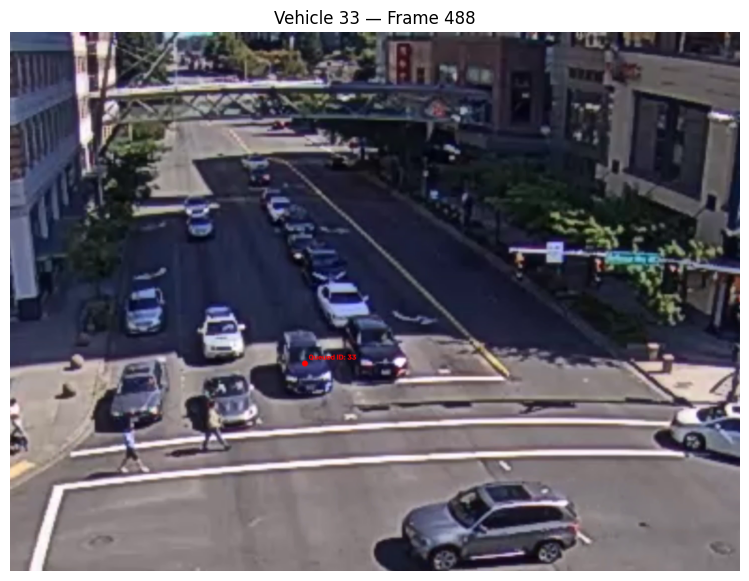

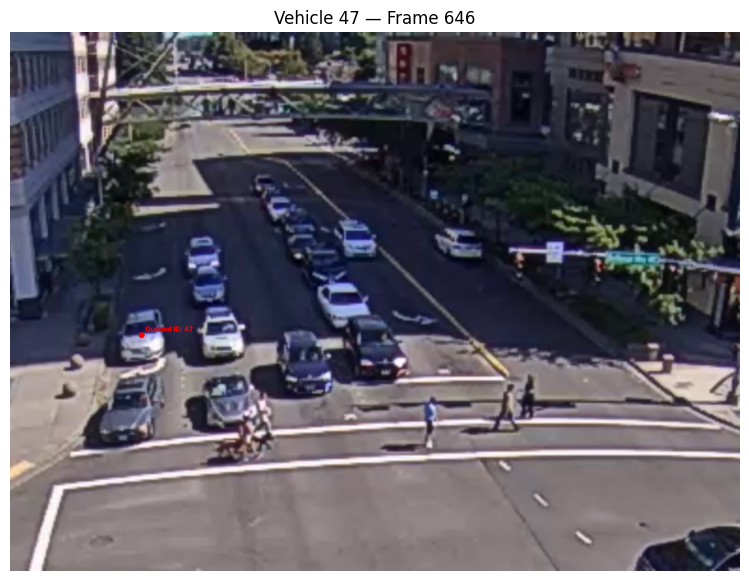

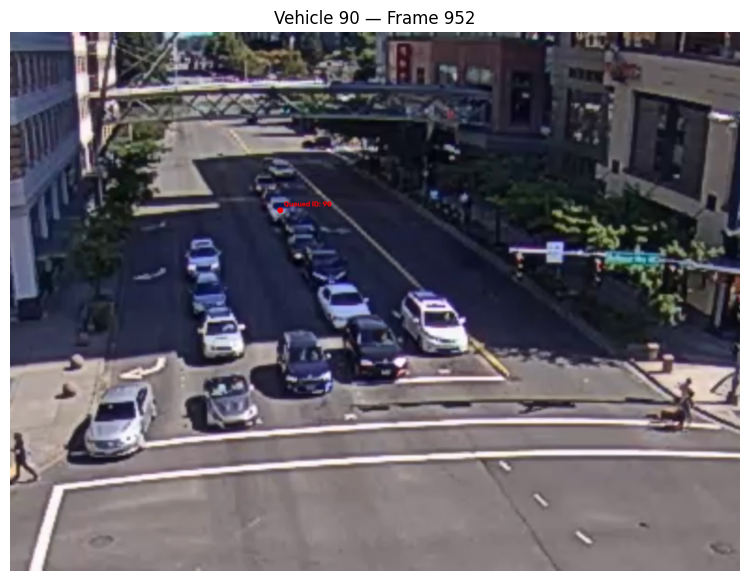

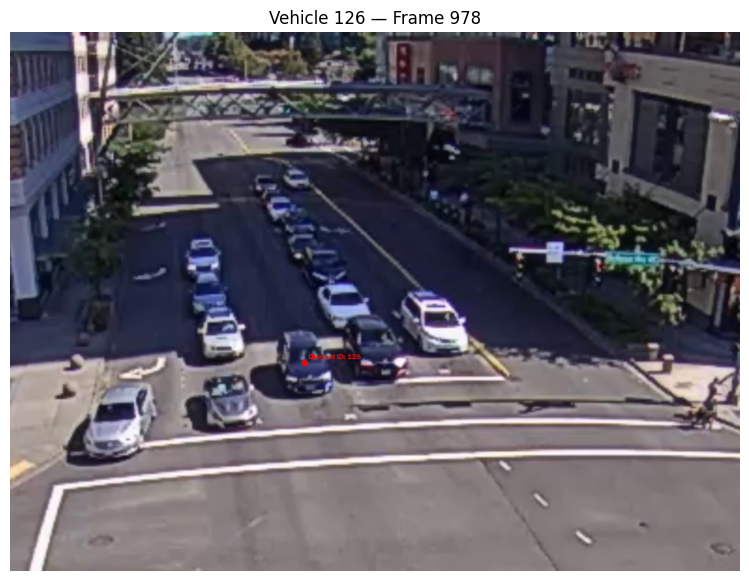

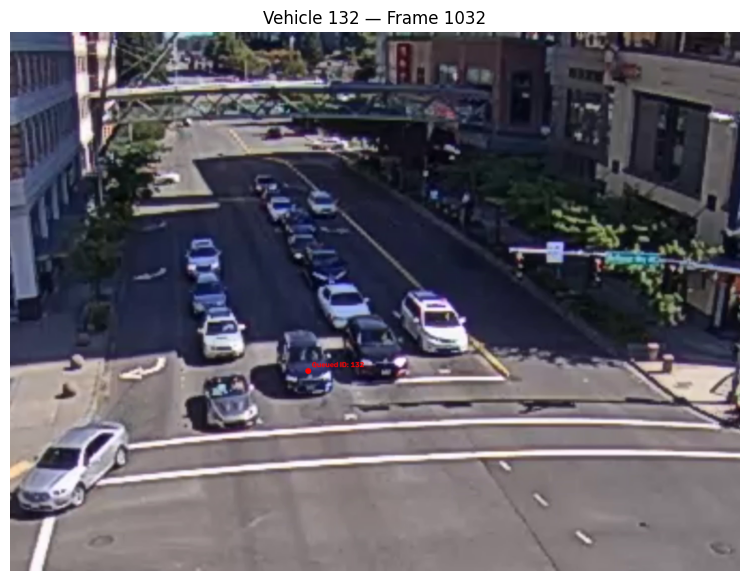

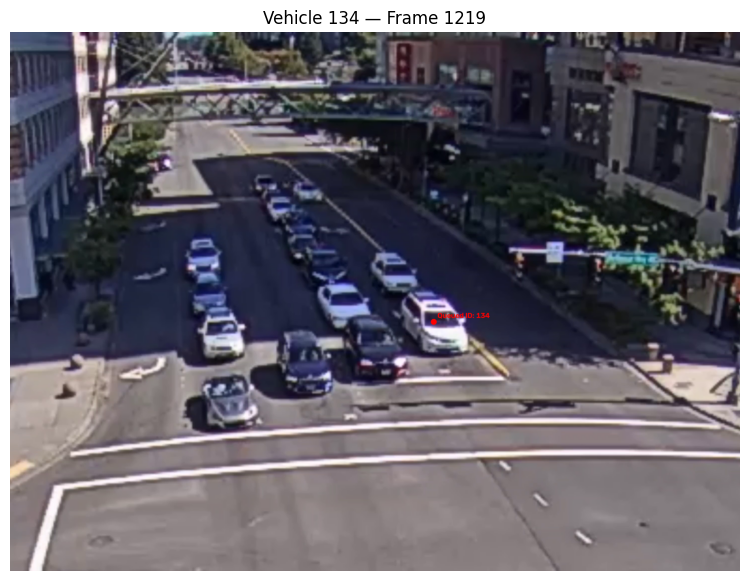

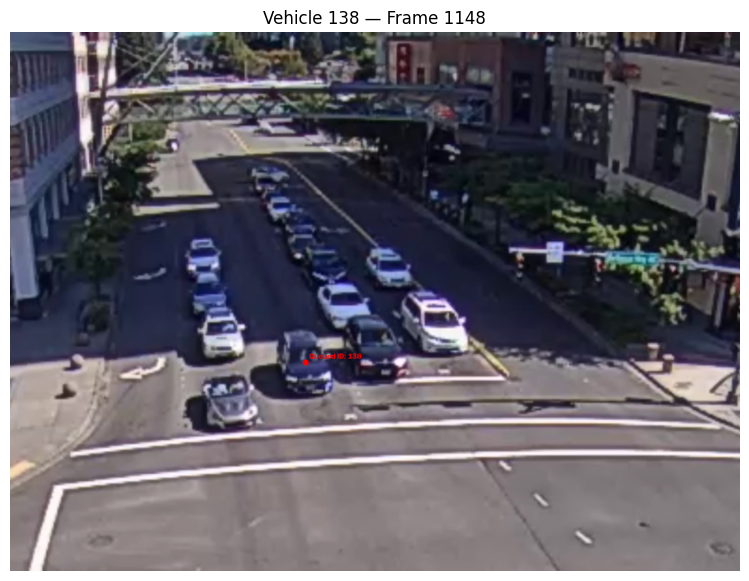

In [31]:
import cv2
import matplotlib.pyplot as plt

video_path = video_path  # use your current video path

cap = cv2.VideoCapture(video_path)

for track_id, frame_no in sample_frames:
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
    ret, frame = cap.read()

    if not ret:
        print(f"Could not read frame {frame_no}")
        continue

    # Find this vehicle's position at the selected frame
    vehicle = df[
        (df["track_id"] == track_id) &
        (df["frame"] == frame_no)
    ]

    if len(vehicle) == 0:
        print(f"Vehicle {track_id} not found at frame {frame_no}")
        continue

    row = vehicle.iloc[0]

    x = int(row["center_x"])
    y = int(row["center_y"])

    # Mark the tracked vehicle center
    cv2.circle(frame, (x, y), 12, (0, 0, 255), -1)

    cv2.putText(
        frame,
        f"Queued ID: {track_id}",
        (x + 15, y - 15),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 0, 255),
        2
    )

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 7))
    plt.imshow(frame_rgb)
    plt.title(f"Vehicle {track_id} — Frame {frame_no}")
    plt.axis("off")
    plt.show()

cap.release()